# Parking Lot IP Scaling Tests: Indefinite Overnight Runner

This notebook is the scaling version of the queued/FIFO parking-lot IP model.

It compares three assignment strategies:

1. `random`
2. `nearest`
3. `furthest`

The runner is designed for long experiments that you can leave running overnight:

- row sizes are processed in order;
- all methods for one `num_rows` value run before moving to the next size;
- results are checkpointed to CSV after every completed method;
- existing results are loaded on restart so the notebook can resume;
- there is **no per-instance time limit**;
- if you stop the notebook with keyboard interrupt, completed/checkpointed runs remain saved;
- plotting uses only balanced, completed rows so incomplete/interrupted/error data is not graphed.


In [2]:
import time
import random
from collections import defaultdict
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    import gurobipy as gp
    from gurobipy import GRB
except ImportError as exc:
    raise ImportError(
        "This notebook requires gurobipy. Run it in the environment where your Gurobi license is configured."
    ) from exc


## 1. Parking-lot graph construction

In [3]:
def build_parking_lot_graph(
    num_rows,
    row_spacing=3.0,
    col_spacing=8.0,
    spot_offset=2.0,
    middle_spot_offset=1.2,
    top_bottom_capacity=3,
    normal_aisle_capacity=1,
    top_bottom_travel_time=3,
    normal_aisle_travel_time=1,
    parking_duration=3,
):
    if num_rows < 3:
        raise ValueError("num_rows must be at least 3.")

    expected_num_spots = (num_rows - 2) * 4

    G = nx.DiGraph()
    pos = {}

    left_col_x = 0
    right_col_x = col_spacing

    for r in range(num_rows):
        y = -r * row_spacing
        left_node = f"L{r}"
        right_node = f"R{r}"

        pos[left_node] = (left_col_x, y)
        pos[right_node] = (right_col_x, y)

        G.add_node(left_node, kind="intersection", node_capacity=1)
        G.add_node(right_node, kind="intersection", node_capacity=1)

        # Top and bottom cross-aisles connect the left and right aisles.
        if r == 0 or r == num_rows - 1:
            for u, v in [(left_node, right_node), (right_node, left_node)]:
                G.add_edge(
                    u,
                    v,
                    travel_time=top_bottom_travel_time,
                    capacity=top_bottom_capacity,
                    edge_type="aisle",
                )

    # Vertical one-lane aisles.
    for r in range(num_rows - 1):
        for u, v in [
            (f"L{r}", f"L{r+1}"),
            (f"L{r+1}", f"L{r}"),
            (f"R{r}", f"R{r+1}"),
            (f"R{r+1}", f"R{r}"),
        ]:
            G.add_edge(
                u,
                v,
                travel_time=normal_aisle_travel_time,
                capacity=normal_aisle_capacity,
                edge_type="aisle",
            )

    entrances = ["E1", "E2"]

    pos["E1"] = (left_col_x, row_spacing)
    pos["E2"] = (right_col_x, -num_rows * row_spacing)

    # Entrances are not node-capacity constrained. They act like external queues.
    G.add_node("E1", kind="entrance")
    G.add_node("E2", kind="entrance")

    G.add_edge("E1", "L0", travel_time=1, capacity=top_bottom_capacity, edge_type="aisle")
    G.add_edge("E2", f"R{num_rows - 1}", travel_time=1, capacity=top_bottom_capacity, edge_type="aisle")

    spot_count = 1

    for r in range(1, num_rows - 1):
        y = -r * row_spacing

        spot_specs = [
            (f"L{r}", left_col_x - spot_offset, y),
            (f"L{r}", left_col_x + spot_offset, y + middle_spot_offset),
            (f"R{r}", right_col_x - spot_offset, y - middle_spot_offset),
            (f"R{r}", right_col_x + spot_offset, y),
        ]

        for aisle_node, x_pos, y_pos in spot_specs:
            spot = f"S{spot_count}"
            spot_count += 1

            pos[spot] = (x_pos, y_pos)
            G.add_node(spot, kind="spot")

            # Entering the spot is the parking maneuver and takes several seconds.
            G.add_edge(
                aisle_node,
                spot,
                travel_time=parking_duration,
                capacity=1,
                edge_type="parking",
            )

            # Reverse edge is only present so the graph remains visually complete.
            # Cars never use it in the fixed entrance-to-spot paths.
            G.add_edge(
                spot,
                aisle_node,
                travel_time=1,
                capacity=1,
                edge_type="spot",
            )

    parking_spots = [
        node for node, data in G.nodes(data=True)
        if data.get("kind") == "spot"
    ]

    if len(parking_spots) != expected_num_spots:
        raise ValueError(
            f"Expected {expected_num_spots} spots, generated {len(parking_spots)}."
        )

    return G, pos, parking_spots, entrances


## 2. Arrival generation and assignment methods

Nearest and furthest assignment are entrance-relative and prefer the car's own aisle side first. Random assignment is unchanged.

In [4]:
def generate_poisson_arrival_times(
    num_cars,
    total_time=30,
    base_rate=0.40,
    peak_rate=2.20,
    peak_time=18,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    arrival_times = []

    for t in range(total_time):
        if t <= peak_time:
            rate = base_rate + (peak_rate - base_rate) * (t / peak_time)
        else:
            rate = peak_rate * max(
                0.15,
                1 - (t - peak_time) / max(1, total_time - peak_time),
            )

        for _ in range(rng.poisson(rate)):
            arrival_times.append(t)

        if len(arrival_times) >= num_cars:
            break

    if len(arrival_times) == 0:
        arrival_times.append(0)

    while len(arrival_times) < num_cars:
        arrival_times.append(arrival_times[-1] + rng.poisson(1) + 1)

    return arrival_times[:num_cars]


def car_number(car):
    return int(car["name"].split()[-1])


def spot_number(spot):
    return int(spot[1:])


def spot_side(spot):
    """Left-side spots are positions 1-2 in each row; right-side spots are positions 3-4."""
    position_in_row = (spot_number(spot) - 1) % 4
    return "L" if position_in_row in [0, 1] else "R"


def car_side(car):
    if car["start"] == "E1":
        return "L"
    if car["start"] == "E2":
        return "R"
    raise ValueError(f"Unknown car entrance: {car['start']}")


def cars_in_arrival_order(cars):
    """Stable physical order used by greedy assignments and entrance FIFO constraints."""
    return sorted(cars, key=lambda car: (car["start_time"], car_number(car)))


def assignment_distance(G, entrance, spot):
    """Shortest-path travel time from this car's entrance to this available spot."""
    return nx.shortest_path_length(G, source=entrance, target=spot, weight="travel_time")


def assignment_tie_breaker(spot):
    """Deterministic tie-breaker so GIFs are reproducible."""
    return spot_number(spot)


def same_side_available_spots(car, available_spots):
    """Prefer spots on the car's own aisle. Fall back only if that side is full."""
    preferred_side = car_side(car)
    same_side = [spot for spot in available_spots if spot_side(spot) == preferred_side]
    return same_side if same_side else list(available_spots)


def assign_random_spots(cars, parking_spots, random_state, G=None):
    chosen_spots = random_state.sample(sorted(parking_spots, key=spot_number), len(cars))

    for car, spot in zip(cars, chosen_spots):
        car["spot"] = spot

    return cars


def assign_nearest_spots(cars, parking_spots, random_state=None, G=None):
    """Greedy nearest-available same-aisle assignment from each car's own entrance."""
    if G is None:
        raise ValueError("G is required for distance-based nearest assignment.")

    available_spots = set(parking_spots)

    for car in cars_in_arrival_order(cars):
        candidate_spots = same_side_available_spots(car, available_spots)
        best_spot = min(
            candidate_spots,
            key=lambda spot: (
                assignment_distance(G, car["start"], spot),
                assignment_tie_breaker(spot),
            ),
        )
        car["spot"] = best_spot
        available_spots.remove(best_spot)

    return cars


def assign_furthest_spots(cars, parking_spots, random_state=None, G=None):
    """Greedy furthest-available same-aisle assignment from each car's own entrance."""
    if G is None:
        raise ValueError("G is required for distance-based furthest assignment.")

    available_spots = set(parking_spots)

    for car in cars_in_arrival_order(cars):
        candidate_spots = same_side_available_spots(car, available_spots)
        best_spot = max(
            candidate_spots,
            key=lambda spot: (
                assignment_distance(G, car["start"], spot),
                -assignment_tie_breaker(spot),
            ),
        )
        car["spot"] = best_spot
        available_spots.remove(best_spot)

    return cars


ASSIGNMENT_FUNCTIONS = {
    "random": assign_random_spots,
    "nearest": assign_nearest_spots,
    "furthest": assign_furthest_spots,
}


def create_cars_for_lot(
    G,
    parking_spots,
    entrances,
    seed=42,
    assignment_method="random",
):
    rng = np.random.default_rng(seed)
    random_state = random.Random(seed)

    num_cars = len(parking_spots)
    arrival_times = generate_poisson_arrival_times(num_cars, rng=rng)

    cars = []

    for i in range(num_cars):
        cars.append({
            "name": f"car {i + 1}",
            "start": entrances[i % len(entrances)],
            "start_time": arrival_times[i],
            "spot": None,
            "path": None,
            "path_edges": None,
            "travel_time": None,
        })

    if assignment_method not in ASSIGNMENT_FUNCTIONS:
        raise ValueError(f"Unknown assignment method: {assignment_method}")

    cars = ASSIGNMENT_FUNCTIONS[assignment_method](
        cars=cars,
        parking_spots=parking_spots,
        random_state=random_state,
        G=G,
    )

    for car in cars:
        if not nx.has_path(G, car["start"], car["spot"]):
            raise ValueError(f"No path from {car['start']} to {car['spot']}.")

        car["path"] = nx.shortest_path(
            G,
            source=car["start"],
            target=car["spot"],
            weight="travel_time",
        )

        car["path_edges"] = list(zip(car["path"][:-1], car["path"][1:]))

        car["travel_time"] = nx.shortest_path_length(
            G,
            source=car["start"],
            target=car["spot"],
            weight="travel_time",
        )

    return cars


## 3. IP helper functions

In [5]:
def edge_duration(G, edge):
    u, v = edge
    return int(G[u][v].get("travel_time", 1))


def is_parking_edge(G, edge):
    u, v = edge
    return G[u][v].get("edge_type") == "parking"


def is_capacity_constrained_node(G, node):
    return G.nodes[node].get("kind") == "intersection"


def physical_edge_key(edge):
    """Group opposite directions of the same physical segment together."""
    u, v = edge
    return tuple(sorted((u, v)))


def physical_edge_capacity(G, physical_key):
    """Use the largest listed directed capacity for the physical segment."""
    u, v = physical_key
    capacities = []
    if G.has_edge(u, v):
        capacities.append(G[u][v].get("capacity", 1))
    if G.has_edge(v, u):
        capacities.append(G[v][u].get("capacity", 1))
    return max(capacities) if capacities else 1


def parking_aisle_node(G, edge):
    u, v = edge
    return u if is_parking_edge(G, edge) else None


## 4. Fixed-path IP solver with node queues and FIFO entrances

The solver is the improved model from the GIF notebook, without animation code.

In [6]:
def incomplete_result(status, elapsed_time, model=None, T=np.nan):
    return {
        "status_code": None,
        "status": status,
        "solver_runtime": 0.0,
        "wall_runtime": elapsed_time,
        "num_vars": np.nan if model is None else model.NumVars,
        "num_constraints": np.nan if model is None else model.NumConstrs,
        "time_horizon": T,
        "has_solution": False,
        "makespan": np.nan,
        "avg_wait_time": np.nan,
        "total_wait_time": np.nan,
        "max_wait_time": np.nan,
        "mip_gap": np.nan,
    }


def solve_fixed_path_ip(
    G,
    cars,
    instance_start_time,
    mip_gap=None,
    output_flag=0,
    gurobi_time_limit_seconds=None,
):
    """Solve the fixed-path parking traffic IP.

    By default there is no per-instance time limit. Set
    gurobi_time_limit_seconds only if you intentionally want Gurobi to stop an
    instance early. The overnight runner leaves this as None.
    """
    def elapsed():
        return time.time() - instance_start_time

    num_cars = len(cars)
    max_arrival_time = max(car["start_time"] for car in cars)

    max_path_duration = max(
        sum(edge_duration(G, edge) for edge in car["path_edges"])
        for car in cars
    )

    max_parking_duration = max(
        edge_duration(G, edge)
        for car in cars
        for edge in car["path_edges"]
        if is_parking_edge(G, edge)
    )

    # Conservative horizon: enough time for every car to park one after another,
    # plus path travel and slack.
    T = max_arrival_time + (num_cars * max_parking_duration) + max_path_duration + 30

    model = gp.Model("fixed_path_ip_with_node_queues")
    model.Params.OutputFlag = output_flag

    if mip_gap is not None:
        model.Params.MIPGap = mip_gap

    x = {}
    y = {}

    # x[c,k,t] = car c starts edge k at time t.
    for c, car in enumerate(cars):
        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            for t in range(T - dur + 1):
                x[c, k, t] = model.addVar(
                    vtype=GRB.BINARY,
                    name=f"x_car{c}_edge{k}_time{t}",
                )

    # y[c,i,t] = car c is at path node i at integer time t.
    for c, car in enumerate(cars):
        for i, node in enumerate(car["path"]):
            for t in range(T + 1):
                y[c, i, t] = model.addVar(
                    vtype=GRB.BINARY,
                    name=f"y_car{c}_node{i}_time{t}",
                )

    finish_time = {
        c: model.addVar(vtype=GRB.INTEGER, lb=0, ub=T, name=f"finish_time_car{c}")
        for c in range(num_cars)
    }

    makespan = model.addVar(vtype=GRB.INTEGER, lb=0, ub=T, name="makespan")
    model.update()

    # Constraint 1: each path edge is traversed exactly once.
    for c, car in enumerate(cars):
        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            model.addConstr(
                gp.quicksum(x[c, k, t] for t in range(T - dur + 1)) == 1,
                name=f"car{c}_edge{k}_once",
            )

    # Constraint 2: path-node flow conservation.
    # Cars enter their entrance node at start_time, then either wait or move forward.
    for c, car in enumerate(cars):
        K = len(car["path_edges"])
        arrival_time = car["start_time"]

        for i, node in enumerate(car["path"]):
            initial_value = 1 if (i == 0 and arrival_time == 0) else 0
            model.addConstr(y[c, i, 0] == initial_value, name=f"initial_car{c}_node{i}")

        for t in range(T):
            for i, node in enumerate(car["path"]):
                depart = 0
                if i < K:
                    edge = car["path_edges"][i]
                    dur = edge_duration(G, edge)
                    if t <= T - dur:
                        depart = x[c, i, t]

                arrive = 0
                if i > 0:
                    prev_edge = car["path_edges"][i - 1]
                    prev_dur = edge_duration(G, prev_edge)
                    start_time_for_arrival = t + 1 - prev_dur
                    if 0 <= start_time_for_arrival <= T - prev_dur:
                        arrive = x[c, i - 1, start_time_for_arrival]

                external_arrival = 1 if (i == 0 and t + 1 == arrival_time) else 0

                model.addConstr(
                    y[c, i, t + 1] == y[c, i, t] - depart + arrive + external_arrival,
                    name=f"flow_car{c}_node{i}_time{t}",
                )

    # Constraint 3: a car can only start an edge if it is currently at that edge's start node.
    for c, car in enumerate(cars):
        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            for t in range(T - dur + 1):
                model.addConstr(
                    x[c, k, t] <= y[c, k, t],
                    name=f"depart_only_if_present_car{c}_edge{k}_time{t}",
                )

    # Constraint 4: physical aisle/parking segment capacities.
    # Opposite directions of the same physical aisle segment share capacity, which prevents passing.
    active_by_physical_edge_time = defaultdict(list)

    for c, car in enumerate(cars):
        for k, edge in enumerate(car["path_edges"]):
            dur = edge_duration(G, edge)
            key = physical_edge_key(edge)
            for start_t in range(T - dur + 1):
                for tau in range(start_t, start_t + dur):
                    active_by_physical_edge_time[key, tau].append(x[c, k, start_t])

    for (physical_key, tau), active_terms in active_by_physical_edge_time.items():
        model.addConstr(
            gp.quicksum(active_terms) <= physical_edge_capacity(G, physical_key),
            name=f"physical_edge_capacity_{physical_key[0]}_{physical_key[1]}_time{tau}",
        )

    # Constraint 5: node capacity and parking blocking.
    # y terms make cars wait in queues at nodes. Parking terms keep the adjacent aisle blocked
    # while a car is pulling into its spot.
    y_terms_by_node_time = defaultdict(list)
    parking_block_terms_by_node_time = defaultdict(list)

    for c, car in enumerate(cars):
        for i, node in enumerate(car["path"]):
            if is_capacity_constrained_node(G, node):
                for tau in range(T + 1):
                    y_terms_by_node_time[node, tau].append(y[c, i, tau])

        for k, edge in enumerate(car["path_edges"]):
            if not is_parking_edge(G, edge):
                continue

            aisle_node = parking_aisle_node(G, edge)
            dur = edge_duration(G, edge)

            for start_t in range(T - dur + 1):
                # At start_t, the car is already counted by y at the aisle node.
                # For the remaining parking seconds, the maneuver continues to block the aisle node.
                for tau in range(start_t + 1, start_t + dur):
                    parking_block_terms_by_node_time[aisle_node, tau].append(x[c, k, start_t])

    constrained_nodes = [
        node for node, data in G.nodes(data=True)
        if is_capacity_constrained_node(G, node)
    ]

    for node in constrained_nodes:
        node_capacity = G.nodes[node].get("node_capacity", 1)

        for tau in range(T + 1):
            terms = []
            terms.extend(y_terms_by_node_time.get((node, tau), []))
            terms.extend(parking_block_terms_by_node_time.get((node, tau), []))

            if terms:
                model.addConstr(
                    gp.quicksum(terms) <= node_capacity,
                    name=f"node_capacity_{node}_time{tau}",
                )

    # Constraint 6: FIFO entrance order.
    # For each entrance, earlier-arriving cars must begin their first movement no later
    # than later-arriving cars. Ties are broken by car number. This prevents Gurobi from
    # improving the objective by letting car 3 enter before car 1 at the same entrance.
    first_start_expr = {}

    for c, car in enumerate(cars):
        first_edge = car["path_edges"][0]
        first_duration = edge_duration(G, first_edge)
        first_start_expr[c] = gp.quicksum(
            t * x[c, 0, t]
            for t in range(T - first_duration + 1)
        )

    cars_by_entrance = defaultdict(list)
    for c, car in enumerate(cars):
        cars_by_entrance[car["start"]].append((c, car))

    for entrance, entrance_cars in cars_by_entrance.items():
        ordered = sorted(
            entrance_cars,
            key=lambda item: (item[1]["start_time"], car_number(item[1])),
        )

        for earlier, later in zip(ordered, ordered[1:]):
            earlier_c, earlier_car = earlier
            later_c, later_car = later
            model.addConstr(
                first_start_expr[earlier_c] <= first_start_expr[later_c],
                name=f"fifo_{entrance}_car{earlier_c}_before_car{later_c}",
            )

    # Constraint 7: finish time definition.
    for c, car in enumerate(cars):
        last_step = len(car["path_edges"]) - 1
        final_edge = car["path_edges"][last_step]
        final_duration = edge_duration(G, final_edge)

        final_start = gp.quicksum(
            t * x[c, last_step, t]
            for t in range(T - final_duration + 1)
        )

        model.addConstr(
            finish_time[c] == final_start + final_duration,
            name=f"finish_time_def_car{c}",
        )

    # Constraint 8: makespan definition.
    for c in range(num_cars):
        model.addConstr(makespan >= finish_time[c], name=f"makespan_after_car{c}")

    model.setObjective(makespan, GRB.MINIMIZE)

    if gurobi_time_limit_seconds is not None:
        model.Params.TimeLimit = float(gurobi_time_limit_seconds)

    model.optimize()

    status_text = {
        GRB.OPTIMAL: "OPTIMAL",
        GRB.TIME_LIMIT: "TIME_LIMIT",
        GRB.INFEASIBLE: "INFEASIBLE",
        GRB.INF_OR_UNBD: "INF_OR_UNBD",
        GRB.UNBOUNDED: "UNBOUNDED",
    }.get(model.status, str(model.status))

    result = {
        "status_code": model.status,
        "status": status_text,
        "solver_runtime": model.Runtime,
        "wall_runtime": elapsed(),
        "num_vars": model.NumVars,
        "num_constraints": model.NumConstrs,
        "time_horizon": T,
        "has_solution": model.SolCount > 0,
        "makespan": np.nan,
        "avg_wait_time": np.nan,
        "total_wait_time": np.nan,
        "max_wait_time": np.nan,
        "mip_gap": np.nan,
    }

    if model.SolCount > 0:
        wait_times = []

        for c, car in enumerate(cars):
            schedule = []

            for k, edge in enumerate(car["path_edges"]):
                dur = edge_duration(G, edge)

                for t in range(T - dur + 1):
                    if x[c, k, t].X > 0.5:
                        schedule.append({
                            "start_time": t,
                            "end_time": t + dur,
                            "duration": dur,
                            "edge": edge,
                            "is_parking": is_parking_edge(G, edge),
                        })

            node_occupancy = []
            for i, node in enumerate(car["path"]):
                for t in range(T + 1):
                    if y[c, i, t].X > 0.5:
                        node_occupancy.append({
                            "time": t,
                            "node": node,
                            "path_index": i,
                        })

            schedule = sorted(schedule, key=lambda item: item["start_time"])
            node_occupancy = sorted(node_occupancy, key=lambda item: item["time"])

            car["ip_schedule"] = schedule
            car["ip_node_occupancy"] = node_occupancy
            car["ip_finish_time"] = int(round(finish_time[c].X))

            minimum_possible_time = sum(edge_duration(G, edge) for edge in car["path_edges"])
            car["ip_wait_time"] = car["ip_finish_time"] - car["start_time"] - minimum_possible_time
            wait_times.append(car["ip_wait_time"])

        result["makespan"] = int(round(makespan.X))
        result["avg_wait_time"] = float(np.mean(wait_times))
        result["total_wait_time"] = float(np.sum(wait_times))
        result["max_wait_time"] = float(np.max(wait_times))

        try:
            result["mip_gap"] = model.MIPGap
        except gp.GurobiError:
            pass

    return result


## 5. Indefinite scaling experiment runner

This section is meant to be safe to leave running for a long time. It checkpoints after every completed `(num_rows, method)` run. If you interrupt the notebook, previously saved rows remain in the CSV file. Re-running the cell resumes from the saved CSV instead of starting over.

There is **no 10-minute timer** anymore. Each instance is allowed to run until Gurobi finishes, errors, or you manually interrupt the notebook.

The loop order is:

```python
for num_rows in row_values:
    for method in assignment_methods:
        run one experiment
```

That gives complete method comparisons for smaller lot sizes before moving on to larger lot sizes.


In [7]:
# -----------------------------
# Indefinite-run configuration
# -----------------------------

ASSIGNMENT_METHODS = ("random", "nearest", "furthest")

# Edit this list freely. The runner processes all methods for one row size before moving on.
ROW_VALUES = [4, 5, 6, 8, 10, 12, 15, 18, 23, 28, 35, 45, 60, 80, 100, 125]

SEED = 42

# No per-instance timer. Leave this as None for indefinite overnight runs.
# If you later want a Gurobi-only cutoff, set this to a number of seconds.
GUROBI_TIME_LIMIT_SECONDS = None

# Keep this as None to require exact optimal solutions. A nonzero gap can make larger runs finish sooner,
# but those results should be described as approximate in the report.
MIP_GAP = None

# Set to True only if you intentionally want to ignore/delete previous indefinite-run results.
CLEAR_EXISTING_RESULTS = False

RESULTS_CSV = Path("assignment_method_scaling_results_queued_fifo_indefinite.csv")
PLOT_DATA_CSV = Path("assignment_method_scaling_plot_data_queued_fifo_indefinite.csv")
BALANCED_PLOT_DATA_CSV = Path("assignment_method_scaling_balanced_plot_data_queued_fifo_indefinite.csv")

# TIME_LIMIT can only occur if GUROBI_TIME_LIMIT_SECONDS is manually set.
BAD_OR_INCOMPLETE_STATUSES = {"ERROR", "INTERRUPTED", "TIME_LIMIT", "INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}


def now_string():
    return datetime.now().isoformat(timespec="seconds")


def load_existing_results(results_csv=RESULTS_CSV, clear_existing=CLEAR_EXISTING_RESULTS):
    if clear_existing and results_csv.exists():
        backup = results_csv.with_suffix(".bak.csv")
        results_csv.replace(backup)
        print(f"Moved previous results to {backup}")
        return pd.DataFrame()

    if results_csv.exists():
        df = pd.read_csv(results_csv)
        print(f"Loaded {len(df)} existing result rows from {results_csv}")
        return df

    print("No existing results file found. Starting a new run.")
    return pd.DataFrame()


def save_results(df, results_csv=RESULTS_CSV):
    """Save results atomically enough for notebook use."""
    tmp_csv = results_csv.with_suffix(".tmp.csv")
    df.to_csv(tmp_csv, index=False)
    tmp_csv.replace(results_csv)


def run_key(num_rows, assignment_method, seed=SEED):
    return (int(num_rows), str(assignment_method), int(seed))


def row_key_from_record(record):
    return run_key(record["num_rows"], record["assignment_method"], record.get("seed", SEED))


def existing_keys(df):
    """Return completed/final run keys already saved to disk.

    ERROR and INTERRUPTED rows are intentionally not treated as final, so those runs
    can be retried after restarting the notebook.
    """
    if df.empty:
        return set()
    required = {"num_rows", "assignment_method", "seed", "status"}
    if not required.issubset(df.columns):
        return set()

    keys = set()
    for _, row in df.iterrows():
        status = row.get("status")
        if status not in {"ERROR", "INTERRUPTED"}:
            keys.add(run_key(row["num_rows"], row["assignment_method"], row.get("seed", SEED)))
    return keys


def upsert_record(df, record):
    """Replace any previous row with the same run key, then append the new row."""
    key = row_key_from_record(record)

    if not df.empty and {"num_rows", "assignment_method", "seed"}.issubset(df.columns):
        keep_mask = ~(
            (df["num_rows"].astype(int) == key[0])
            & (df["assignment_method"].astype(str) == key[1])
            & (df["seed"].fillna(SEED).astype(int) == key[2])
        )
        df = df.loc[keep_mask].copy()

    df = pd.concat([df, pd.DataFrame([record])], ignore_index=True)
    df = df.sort_values(["num_rows", "assignment_method", "seed"], kind="stable").reset_index(drop=True)
    return df


def is_graphable_result(result):
    """Return True only for completed exact rows that should be plotted."""
    return (
        result.get("status") == "OPTIMAL"
        and result.get("has_solution", False)
        and not pd.isna(result.get("makespan", np.nan))
    )


def error_record(num_rows, assignment_method, error, elapsed_time, seed=SEED):
    return {
        "num_rows": num_rows,
        "num_spots": np.nan,
        "num_cars": np.nan,
        "assignment_method": assignment_method,
        "seed": seed,
        "timestamp_start": None,
        "timestamp_end": now_string(),
        "is_graphable": False,
        "status_code": None,
        "status": "ERROR",
        "error_type": type(error).__name__,
        "error_message": str(error),
        "solver_runtime": 0.0,
        "wall_runtime": elapsed_time,
        "num_vars": np.nan,
        "num_constraints": np.nan,
        "time_horizon": np.nan,
        "has_solution": False,
        "makespan": np.nan,
        "avg_wait_time": np.nan,
        "total_wait_time": np.nan,
        "max_wait_time": np.nan,
        "mip_gap": np.nan,
    }


def run_one_scaling_instance(num_rows, assignment_method, seed=SEED):
    timestamp_start = now_string()
    instance_start = time.time()

    G, pos, parking_spots, entrances = build_parking_lot_graph(num_rows)
    cars = create_cars_for_lot(
        G,
        parking_spots,
        entrances,
        seed=seed,
        assignment_method=assignment_method,
    )

    result = solve_fixed_path_ip(
        G,
        cars,
        instance_start_time=instance_start,
        mip_gap=MIP_GAP,
        output_flag=0,
        gurobi_time_limit_seconds=GUROBI_TIME_LIMIT_SECONDS,
    )

    graphable = is_graphable_result(result)

    return {
        "num_rows": num_rows,
        "num_spots": len(parking_spots),
        "num_cars": len(cars),
        "assignment_method": assignment_method,
        "seed": seed,
        "timestamp_start": timestamp_start,
        "timestamp_end": now_string(),
        "is_graphable": graphable,
        **result,
    }


def run_indefinite_scaling_experiment(
    row_values=ROW_VALUES,
    assignment_methods=ASSIGNMENT_METHODS,
    seed=SEED,
):
    results_df = load_existing_results()
    done_keys = existing_keys(results_df)

    print("Run order: grouped by num_rows, then assignment method")
    print("No per-instance time limit is active.")

    try:
        for num_rows in row_values:
            print(f"\n=== num_rows = {num_rows} ===")

            for assignment_method in assignment_methods:
                key = run_key(num_rows, assignment_method, seed)

                if key in done_keys:
                    print(f"Skipping existing result: num_rows={num_rows}, method={assignment_method}")
                    continue

                print(f"Running: num_rows={num_rows}, method={assignment_method}")
                run_start = time.time()

                try:
                    record = run_one_scaling_instance(
                        num_rows=num_rows,
                        assignment_method=assignment_method,
                        seed=seed,
                    )
                except KeyboardInterrupt:
                    print("KeyboardInterrupt received during current run.")
                    print("Previously completed/checkpointed results have already been saved.")
                    raise
                except Exception as exc:
                    record = error_record(
                        num_rows=num_rows,
                        assignment_method=assignment_method,
                        seed=seed,
                        error=exc,
                        elapsed_time=time.time() - run_start,
                    )

                results_df = upsert_record(results_df, record)
                save_results(results_df)
                done_keys.add(key)

                print(
                    f"Saved: num_rows={num_rows}, method={assignment_method}, "
                    f"status={record.get('status')}, graphable={record.get('is_graphable')}, "
                    f"wall={record.get('wall_runtime', np.nan):.1f}s, "
                    f"solver={record.get('solver_runtime', np.nan):.1f}s, "
                    f"makespan={record.get('makespan')}"
                )

    except KeyboardInterrupt:
        save_results(results_df)
        print(f"\nInterrupted. Saved {len(results_df)} completed/checkpointed rows to {RESULTS_CSV}.")
        return results_df

    save_results(results_df)
    print(f"\nFinished available run list. Saved {len(results_df)} rows to {RESULTS_CSV}.")
    return results_df


## 6. Run or resume the indefinite experiment

Run the cell below to start or resume the experiment. It is safe to stop with keyboard interrupt. Completed rows are already saved after each method finishes. The currently running instance may not be saved if you interrupt during the Gurobi solve, but all previous completed runs remain in the CSV.


In [ ]:
results_df = run_indefinite_scaling_experiment()
results_df

Loaded 3 existing result rows from assignment_method_scaling_results_queued_fifo_indefinite.csv
Run order: grouped by num_rows, then assignment method
No per-instance time limit is active.

=== num_rows = 4 ===
Running: num_rows=4, method=random
Set parameter Username
Set parameter LicenseID to value 2768089
Academic license - for non-commercial use only - expires 2027-01-20
Saved: num_rows=4, method=random, status=OPTIMAL, graphable=True, wall=0.4s, solver=0.3s, makespan=17
Running: num_rows=4, method=nearest
Saved: num_rows=4, method=nearest, status=OPTIMAL, graphable=True, wall=0.4s, solver=0.3s, makespan=16
Running: num_rows=4, method=furthest
Saved: num_rows=4, method=furthest, status=OPTIMAL, graphable=True, wall=0.3s, solver=0.2s, makespan=13

=== num_rows = 5 ===
Running: num_rows=5, method=random
Saved: num_rows=5, method=random, status=OPTIMAL, graphable=True, wall=2.3s, solver=2.0s, makespan=20
Running: num_rows=5, method=nearest
Saved: num_rows=5, method=nearest, status=OPT

## 7. Prepare plotting data

`results_df` keeps every attempted row. `plot_df` keeps all individually graphable rows. `balanced_plot_df` is stricter: it only keeps row sizes where every assignment method has a graphable result. The plots use `balanced_plot_df` by default so incomplete, interrupted, or errored row sizes are not compared unfairly.


In [8]:
# Load from disk if this section is run in a fresh kernel after the overnight run.
if "results_df" not in globals() or results_df is None or results_df.empty:
    results_df = load_existing_results(clear_existing=False)

plot_df = results_df[results_df.get("is_graphable", False) == True].copy()

if plot_df.empty:
    balanced_plot_df = plot_df.copy()
else:
    required_methods = set(ASSIGNMENT_METHODS)
    complete_row_sizes = []

    for num_rows, group in plot_df.groupby("num_rows"):
        methods_present = set(group["assignment_method"])
        if required_methods.issubset(methods_present):
            complete_row_sizes.append(num_rows)

    balanced_plot_df = plot_df[plot_df["num_rows"].isin(complete_row_sizes)].copy()

# Save both datasets. The balanced file is the safest one to use for final figures.
plot_df.to_csv(PLOT_DATA_CSV, index=False)
balanced_plot_df.to_csv(BALANCED_PLOT_DATA_CSV, index=False)

print(f"Total saved rows: {len(results_df)}")
print(f"Individually graphable rows: {len(plot_df)}")
print(f"Balanced graphable rows: {len(balanced_plot_df)}")
print("Balanced row sizes:", sorted(balanced_plot_df["num_rows"].unique()) if not balanced_plot_df.empty else [])

balanced_plot_df

Loaded 15 existing result rows from assignment_method_scaling_results_queued_fifo_indefinite.csv
Total saved rows: 15
Individually graphable rows: 15
Balanced graphable rows: 15
Balanced row sizes: [np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10)]


,num_rows,num_spots,num_cars,assignment_method,seed,timestamp_start,timestamp_end,is_graphable,status_code,status,...,wall_runtime,num_vars,num_constraints,time_horizon,has_solution,makespan,avg_wait_time,total_wait_time,max_wait_time,mip_gap
0,4,8,8,furthest,42,2026-05-18T02:09:50,2026-05-18T02:09:50,True,2,OPTIMAL,...,0.316787,4189,5536,65,True,13,1.375000,11.0,3.0,0.0
1,4,8,8,nearest,42,2026-05-18T02:09:49,2026-05-18T02:09:50,True,2,OPTIMAL,...,0.365518,4189,5536,65,True,16,2.375000,19.0,5.0,0.0
2,4,8,8,random,42,2026-05-18T02:09:49,2026-05-18T02:09:49,True,2,OPTIMAL,...,0.433426,4925,6746,68,True,17,2.125000,17.0,6.0,0.0
3,5,12,12,furthest,42,2026-05-18T02:09:53,2026-05-18T02:09:54,True,2,OPTIMAL,...,0.750455,8797,11142,81,True,17,2.083333,25.0,4.0,0.0
4,5,12,12,nearest,42,2026-05-18T02:09:52,2026-05-18T02:09:53,True,2,OPTIMAL,...,1.149465,8797,11142,81,True,23,3.750000,45.0,8.0,0.0
5,5,12,12,random,42,2026-05-18T02:09:50,2026-05-18T02:09:52,True,2,OPTIMAL,...,2.261326,10123,13064,84,True,20,2.833333,34.0,8.0,0.0
6,6,16,16,furthest,42,2026-05-18T02:05:29,2026-05-18T02:05:30,True,2,OPTIMAL,...,1.658160,15273,18804,95,True,21,3.000000,48.0,7.0,0.0
7,6,16,16,nearest,42,2026-05-18T02:05:23,2026-05-18T02:05:29,True,2,OPTIMAL,...,5.642511,15273,18804,95,True,30,5.875000,94.0,13.0,0.0
8,6,16,16,random,42,2026-05-18T02:05:17,2026-05-18T02:05:23,True,2,OPTIMAL,...,6.338972,18093,22334,98,True,28,5.000000,80.0,13.0,0.0
9,8,24,24,furthest,42,2026-05-18T02:11:44,2026-05-18T02:12:03,True,2,OPTIMAL,...,18.756312,36997,43844,128,True,29,5.208333,125.0,10.0,0.0


## 8. Status summary

This table is useful for checking what finished, what errored, and what was interrupted. Since there is no per-instance timer, you should usually expect completed rows to be `OPTIMAL` unless Gurobi proves infeasibility or the run errors.


In [9]:
if results_df.empty:
    print("No results to summarize yet.")
else:
    summary_table = (
        results_df
        .pivot_table(
            index="num_rows",
            columns="assignment_method",
            values="status",
            aggfunc="last",
        )
        .reindex(index=ROW_VALUES)
    )
    summary_table

## 9. Plotting helpers

All plots below use `balanced_plot_df`, not the full results file. This avoids graphing any row size where one or more methods was interrupted, errored, infeasible, or otherwise incomplete.


In [10]:
def plot_metric_by_method(
    plot_df,
    metric,
    ylabel,
    title,
):
    if plot_df.empty:
        print(f"Skipping plot: {title}. No balanced graphable rows are available.")
        return

    plt.figure(figsize=(8, 5))

    for method in ASSIGNMENT_METHODS:
        group = plot_df[plot_df["assignment_method"] == method].sort_values("num_spots")
        if group.empty:
            continue

        plt.plot(
            group["num_spots"],
            group[metric],
            marker="o",
            label=method,
        )

    plt.xlabel("Number of cars/spots")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


## 10. Individual comparison plots

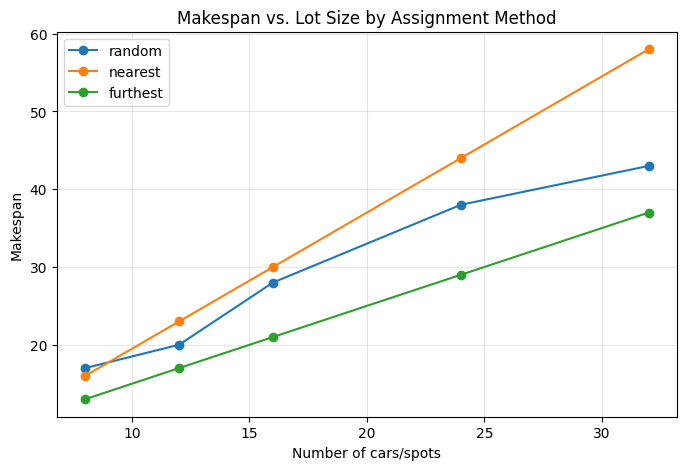

In [11]:
plot_metric_by_method(
    balanced_plot_df,
    metric="makespan",
    ylabel="Makespan",
    title="Makespan vs. Lot Size by Assignment Method",
)

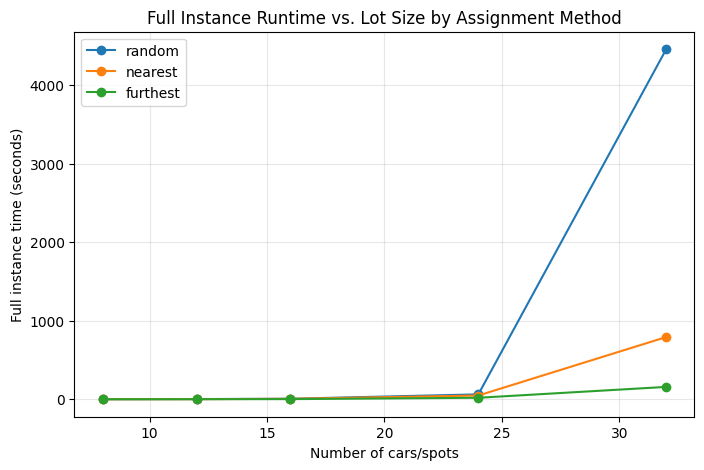

In [12]:
plot_metric_by_method(
    balanced_plot_df,
    metric="wall_runtime",
    ylabel="Full instance time (seconds)",
    title="Full Instance Runtime vs. Lot Size by Assignment Method",
)

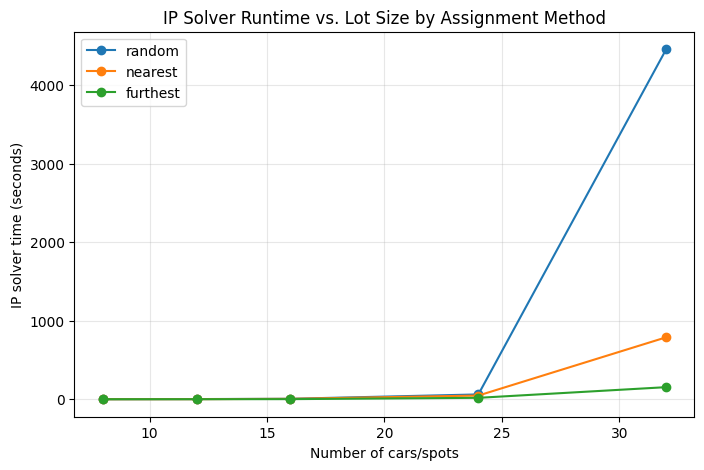

In [13]:
plot_metric_by_method(
    balanced_plot_df,
    metric="solver_runtime",
    ylabel="IP solver time (seconds)",
    title="IP Solver Runtime vs. Lot Size by Assignment Method",
)

## 11. Stacked comparison plot

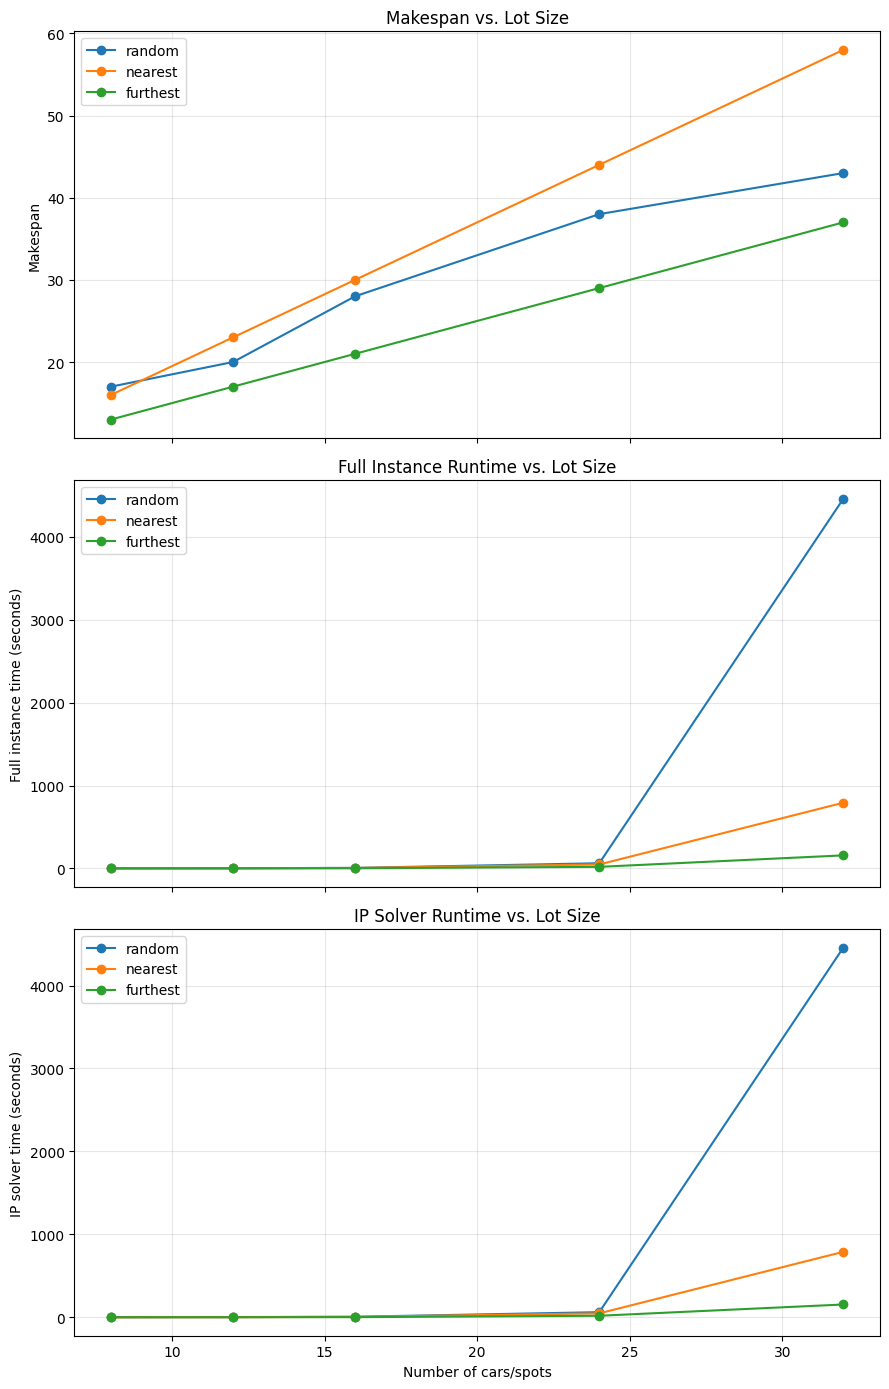

In [14]:
if balanced_plot_df.empty:
    print("Skipping stacked plot because no balanced graphable rows are available.")
else:
    fig, axes = plt.subplots(3, 1, figsize=(9, 14), sharex=True)

    plot_specs = [
        ("makespan", "Makespan", "Makespan vs. Lot Size"),
        ("wall_runtime", "Full instance time (seconds)", "Full Instance Runtime vs. Lot Size"),
        ("solver_runtime", "IP solver time (seconds)", "IP Solver Runtime vs. Lot Size"),
    ]

    for ax, (metric, ylabel, title) in zip(axes, plot_specs):
        for method in ASSIGNMENT_METHODS:
            group = balanced_plot_df[balanced_plot_df["assignment_method"] == method].sort_values("num_spots")
            if group.empty:
                continue

            ax.plot(
                group["num_spots"],
                group[metric],
                marker="o",
                label=method,
            )

        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[-1].set_xlabel("Number of cars/spots")

    plt.tight_layout()
    plt.show()


## 12. Final saved files

- `assignment_method_scaling_results_queued_fifo_indefinite.csv` contains every saved row, including errors and interrupted/retried runs.
- `assignment_method_scaling_plot_data_queued_fifo_indefinite.csv` contains individually graphable rows.
- `assignment_method_scaling_balanced_plot_data_queued_fifo_indefinite.csv` contains only row sizes where all three methods completed cleanly.


In [15]:
save_results(results_df, RESULTS_CSV)
plot_df.to_csv(PLOT_DATA_CSV, index=False)
balanced_plot_df.to_csv(BALANCED_PLOT_DATA_CSV, index=False)

print(f"Saved full results to: {RESULTS_CSV}")
print(f"Saved graphable rows to: {PLOT_DATA_CSV}")
print(f"Saved balanced graphable rows to: {BALANCED_PLOT_DATA_CSV}")

results_df

Saved full results to: assignment_method_scaling_results_queued_fifo_indefinite.csv
Saved graphable rows to: assignment_method_scaling_plot_data_queued_fifo_indefinite.csv
Saved balanced graphable rows to: assignment_method_scaling_balanced_plot_data_queued_fifo_indefinite.csv


,num_rows,num_spots,num_cars,assignment_method,seed,timestamp_start,timestamp_end,is_graphable,status_code,status,...,wall_runtime,num_vars,num_constraints,time_horizon,has_solution,makespan,avg_wait_time,total_wait_time,max_wait_time,mip_gap
0,4,8,8,furthest,42,2026-05-18T02:09:50,2026-05-18T02:09:50,True,2,OPTIMAL,...,0.316787,4189,5536,65,True,13,1.375000,11.0,3.0,0.0
1,4,8,8,nearest,42,2026-05-18T02:09:49,2026-05-18T02:09:50,True,2,OPTIMAL,...,0.365518,4189,5536,65,True,16,2.375000,19.0,5.0,0.0
2,4,8,8,random,42,2026-05-18T02:09:49,2026-05-18T02:09:49,True,2,OPTIMAL,...,0.433426,4925,6746,68,True,17,2.125000,17.0,6.0,0.0
3,5,12,12,furthest,42,2026-05-18T02:09:53,2026-05-18T02:09:54,True,2,OPTIMAL,...,0.750455,8797,11142,81,True,17,2.083333,25.0,4.0,0.0
4,5,12,12,nearest,42,2026-05-18T02:09:52,2026-05-18T02:09:53,True,2,OPTIMAL,...,1.149465,8797,11142,81,True,23,3.750000,45.0,8.0,0.0
5,5,12,12,random,42,2026-05-18T02:09:50,2026-05-18T02:09:52,True,2,OPTIMAL,...,2.261326,10123,13064,84,True,20,2.833333,34.0,8.0,0.0
6,6,16,16,furthest,42,2026-05-18T02:05:29,2026-05-18T02:05:30,True,2,OPTIMAL,...,1.658160,15273,18804,95,True,21,3.000000,48.0,7.0,0.0
7,6,16,16,nearest,42,2026-05-18T02:05:23,2026-05-18T02:05:29,True,2,OPTIMAL,...,5.642511,15273,18804,95,True,30,5.875000,94.0,13.0,0.0
8,6,16,16,random,42,2026-05-18T02:05:17,2026-05-18T02:05:23,True,2,OPTIMAL,...,6.338972,18093,22334,98,True,28,5.000000,80.0,13.0,0.0
9,8,24,24,furthest,42,2026-05-18T02:11:44,2026-05-18T02:12:03,True,2,OPTIMAL,...,18.756312,36997,43844,128,True,29,5.208333,125.0,10.0,0.0
